## Jacobi Algorithm

In [31]:
import numpy as np
def jacobi(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    y=np.zeros(max_iterations)
    for k in range(max_iterations):
        x_new = np.zeros_like(x)
        for i in range(n):
            s = sum(A[i][j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i][i]
        # Check for convergence
        y[k]=np.abs(np.sqrt(np.sum(x_new**2))-np.sqrt(np.sum(x**2)))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            z=y[0:k]
            return z,x_new, k
        x = x_new
    return y, x, max_iterations

## Gauss-Seidel Algorithm

In [32]:
import numpy as np
def gauss_seidel(A, b, x0, tol, max_iterations):
    n = len(b)
    x = x0.copy()
    y=np.zeros(max_iterations)
    for k in range(max_iterations):
        x_new = x.copy()
        for i in range(n):
            s1 = sum(A[i][j] * x_new[j] for j in range(i)) # Using already updated values
            s2 = sum(A[i][j] * x[j] for j in range(i + 1, n)) # Using old values
            x_new[i] = (b[i] - s1 - s2) / A[i][i]
        # Check for convergence
        y[k]=np.abs(np.sqrt(np.sum(x_new**2))-np.sqrt(np.sum(x**2)))
        if np.linalg.norm(x_new - x, ord=np.inf) < tol:
            z=y[0:k]
            return z,x_new, k
        x = x_new
    return y,x, max_iterations

## Main

In [33]:
A=np.array([[3, -.1, -.2],[.1, 7, -.3],[.3, -.2, 10]])
b=np.array([7.85, -19.3, 71.4])
x0 = np.zeros_like(b)
tol = np.array([1e-3, 1e-6, 1e-9])
max_iterations = 100
y=np.zeros(3)
z=np.zeros(3)
for i in range(0,3):
    error1, solution, iterations = jacobi(A, b, x0, tol[i], max_iterations)
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}")
    
#gauss
for i in range(0,3):
    error2, solution, iterations = gauss_seidel(A, b, x0, tol[i], max_iterations)
    print(f"Solution: {solution}")
    print(f"Iterations: {iterations}")
    
error1, solution, iterations = jacobi(A, b, x0, tol[2], max_iterations)
error2, solution, iterations = gauss_seidel(A, b, x0, tol[2], max_iterations)
print(error1.size, error1)
print(error2.size,error2)

Solution: [ 3.0000225  -2.50000266  6.99998104]
Iterations: 3
Solution: [ 3.  -2.5  7. ]
Iterations: 6
Solution: [ 3.  -2.5  7. ]
Iterations: 8
Solution: [ 3.00000035 -2.50000004  6.99999999]
Iterations: 3
Solution: [ 3.  -2.5  7. ]
Iterations: 4
Solution: [ 3.  -2.5  7. ]
Iterations: 6
8 [8.08878119e+00 7.09034699e-02 1.86722058e-03 4.08037808e-04
 6.51834501e-06 7.75517023e-07 1.47035735e-08 1.65912084e-09]
6 [7.98341234e+00 2.88047848e-02 3.40021504e-03 7.43423249e-06
 1.33753879e-07 5.37708544e-10]


The number of iterations that the Gauss-Seidel took was lower for every tolerance except for the largest where the number of iterations was equal to the Jacobi method. The lower tolerances led to an increase in the amount of iterations needed to converge.

## Plot routine:

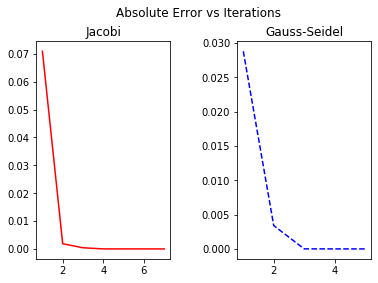

In [45]:
import matplotlib.pyplot as plt
plt.figure()
plt.subplot(1,2,1)
plt.suptitle('Absolute Error vs Iterations', y=1)
plt.plot(np.arange(1,error1.size),error1[1:], '-r')
plt.title("Jacobi")
plt.subplot(1,2,2)
plt.plot(np.arange(1,error2.size),error2[1:], '--b')
plt.title("Gauss-Seidel")
plt.subplots_adjust(wspace=.5)
plt.show()